# 12.5 Implementing Random Forests using Python

In [1]:
# CH.SC.U4CSE24119 Kavin JS

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
from sklearn.metrics import classification_report
import seaborn as sn
import matplotlib.pyplot as plt
from sklearn import tree

## Importing (Reading) Datasets

In [2]:
data = pd.read_csv('../Data/breast_cancer_master.csv')
print(data.shape)
data.head()

(569, 32)


,id,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,842302,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,M
1,842517,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,M
2,84300903,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,M
3,84348301,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,M
4,84358402,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,M


## Assigning dependent and independent variables

In [3]:
x = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

## Splitting the dataset into Training and Testing Dataset

In [4]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=41)

## Preprocessing Data with StandardScaler

In [5]:
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

## Fitting the Model - Random Forest Classifier

In [6]:
model = RandomForestClassifier(n_estimators=10, criterion='entropy', random_state=0)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

## Evaluation Metrics

In [7]:
print('Random Forest Classifier')
conf_mat = metrics.confusion_matrix(y_test, y_pred)
print('\nConfusion Matrix : \n', conf_mat)
Accuracy_score = metrics.accuracy_score(y_test, y_pred)
print('Accuracy Score : ', Accuracy_score)
print('Accuracy in Percentage : ', int(Accuracy_score * 100), '%')
print('\n', classification_report(y_pred, y_test))

Random Forest Classifier

Confusion Matrix : 
 [[110   0]
 [  1  60]]
Accuracy Score :  0.9941520467836257
Accuracy in Percentage :  99 %

               precision    recall  f1-score   support

           B       1.00      0.99      1.00       111
           M       0.98      1.00      0.99        60

    accuracy                           0.99       171
   macro avg       0.99      1.00      0.99       171
weighted avg       0.99      0.99      0.99       171



## Confusion Matrix Heatmap

[Text(0.5, 1.0, 'Random Forest Classifier')]

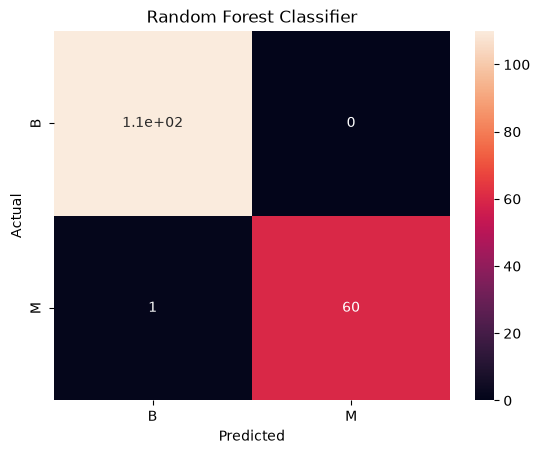

In [8]:
conf_mat = pd.crosstab(y_test, y_pred, rownames=['Actual'], colnames=['Predicted'])
sn.heatmap(conf_mat, annot=True).set(title='Random Forest Classifier')

## Visualizing a Tree from the Forest

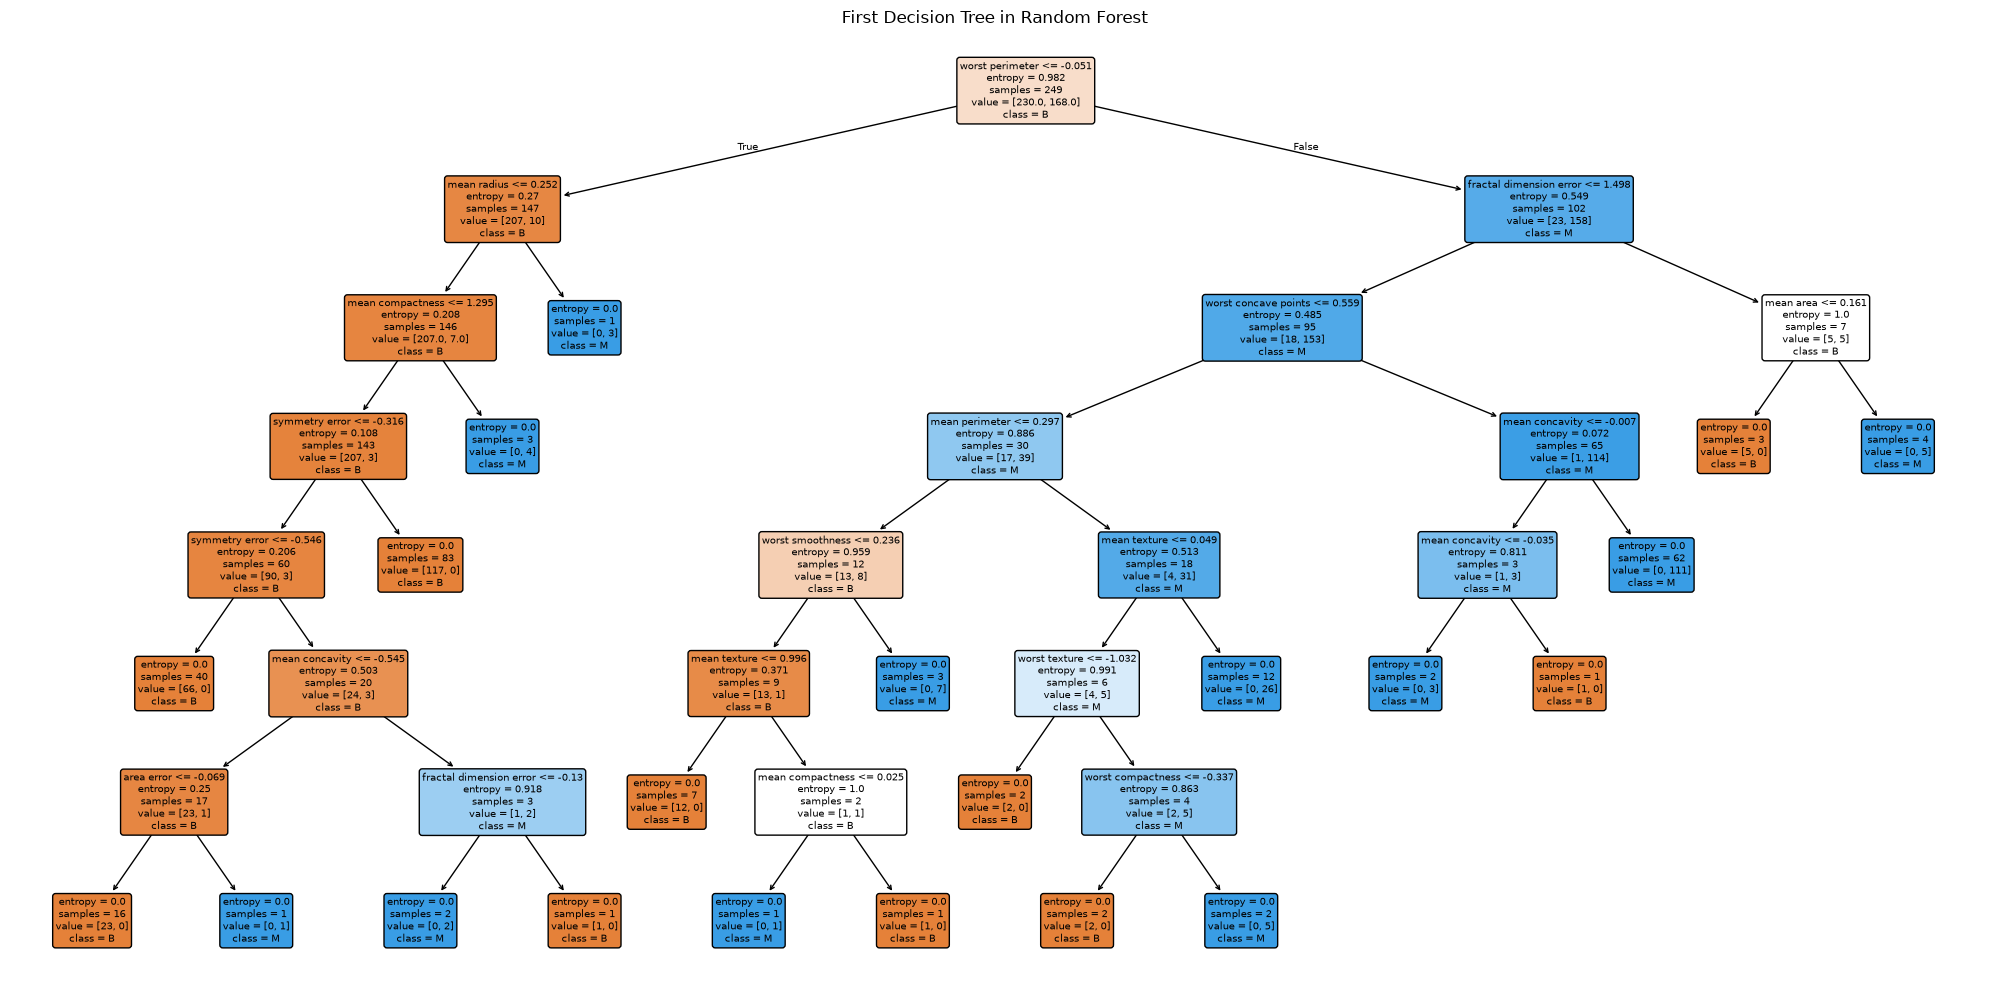

In [9]:
plt.figure(figsize=(20, 10))
tree.plot_tree(model.estimators_[0],
               feature_names=data.columns[:-1],
               class_names=['B', 'M'],
               filled=True, rounded=True, fontsize=7)
plt.title('First Decision Tree in Random Forest')
plt.tight_layout()
plt.show()

## Tree Text Representation

In [10]:
from sklearn.tree import export_text
print(export_text(model.estimators_[0], feature_names=list(data.columns[:-1]), max_depth=3))

|--- worst perimeter <= -0.05
|   |--- mean radius <= 0.25
|   |   |--- mean compactness <= 1.30
|   |   |   |--- symmetry error <= -0.32
|   |   |   |   |--- truncated branch of depth 4
|   |   |   |--- symmetry error >  -0.32
|   |   |   |   |--- class: 0.0
|   |   |--- mean compactness >  1.30
|   |   |   |--- class: 1.0
|   |--- mean radius >  0.25
|   |   |--- class: 1.0
|--- worst perimeter >  -0.05
|   |--- fractal dimension error <= 1.50
|   |   |--- worst concave points <= 0.56
|   |   |   |--- mean perimeter <= 0.30
|   |   |   |   |--- truncated branch of depth 4
|   |   |   |--- mean perimeter >  0.30
|   |   |   |   |--- truncated branch of depth 4
|   |   |--- worst concave points >  0.56
|   |   |   |--- mean concavity <= -0.01
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- mean concavity >  -0.01
|   |   |   |   |--- class: 1.0
|   |--- fractal dimension error >  1.50
|   |   |--- mean area <= 0.16
|   |   |   |--- class: 0.0
|   |   |--- mean area > 